# ChemAI: Predict the Cure

**Задача.** Регрессионное предсказание трёх биологических показателей для химических соединений против вируса гриппа:

- `IC50, mM` — концентрация полуингибирования вирусной активности
- `CC50, mM` — цитотоксическая концентрация (50% гибели клеток)
- `SI` = `CC50 / IC50` — индекс селективности

Дано **751** строка train и **250** строк test, по 210 RDKit-дескрипторов на молекулу. Метрика — RMSE.

**План работы:**

1. EDA — распределения, дубликаты, цензурирование, drift
2. Feature engineering — domain-aware (Lipinski, censoring flags, ratios, group aggregates)
3. Дедупликация близких молекул с агрегацией таргетов
4. Сравнение моделей и выбор финального стека
5. Mixup-аугментация + clean-subset для SI
6. Optuna-тюнинг параметров
7. OOF-стэкинг через Ridge
8. Submission


## Public Score: 290.09

![Kaggle result](kaggle_result.png)


## 1. Окружение

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.ensemble import ExtraTreesRegressor
from catboost import CatBoostRegressor

SEED        = 42
N_FOLDS     = 5
TARGETS     = ['IC50', 'CC50', 'SI']
TARGET_COLS = {'IC50': 'IC50, mM', 'CC50': 'CC50, mM', 'SI': 'SI'}

np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

## 2. Загрузка

In [11]:
train_raw = pd.read_csv('./data/train.csv')
test_raw  = pd.read_csv('./data/test.csv')

print(f'train: {train_raw.shape}')
print(f'test:  {test_raw.shape}')
train_raw.head(3)

train: (751, 214)
test:  (250, 211)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0


## 3. Exploratory Data Analysis

### 3.1. Структура и пропуски

In [12]:
dtypes = train_raw.dtypes.value_counts()
print('Распределение типов:')
print(dtypes.to_string())
print(f'\nКонстантных колонок в train: {(train_raw.nunique() <= 1).sum()}')
print(f'Константных колонок в test:  {(test_raw.nunique()  <= 1).sum()}')

Распределение типов:
int64      107
float64    107

Константных колонок в train: 18
Константных колонок в test:  22


In [13]:
na_train = train_raw.isna().sum()
na_test  = test_raw.isna().sum()
na_summary = pd.DataFrame({
    'na_train': na_train[na_train > 0],
    'na_test':  na_test [na_test  > 0],
}).fillna(0).astype(int)

print(f'Колонок с пропусками: train={na_summary["na_train"].astype(bool).sum()}  '
      f'test={na_summary["na_test"].astype(bool).sum()}')
print(f'Всего ячеек с NA в train: {na_train.sum()}, в test: {na_test.sum()}')
if len(na_summary):
    print('\nПо колонкам:')
    print(na_summary)

Колонок с пропусками: train=12  test=12
Всего ячеек с NA в train: 24, в test: 12

По колонкам:
                     na_train  na_test
MaxPartialCharge            2        1
MinPartialCharge            2        1
MaxAbsPartialCharge         2        1
MinAbsPartialCharge         2        1
BCUT2D_MWHI                 2        1
BCUT2D_MWLOW                2        1
BCUT2D_CHGHI                2        1
BCUT2D_CHGLO                2        1
BCUT2D_LOGPHI               2        1
BCUT2D_LOGPLOW              2        1
BCUT2D_MRHI                 2        1
BCUT2D_MRLOW                2        1


**Выводы 3.1.**

- Пропуски сосредоточены в `MaxPartialCharge`, `MinPartialCharge`, BCUT2D-семействе — 2 строки в каждой колонке. Это обычно бывает у молекул с особенностями расчёта частичных зарядов в RDKit; заполним медианой trainа.
- В test есть несколько колонок, константных в train или в test — их безопасно удалить из feature-сета.

### 3.2. Целевые переменные

In [14]:
train = train_raw.rename({'IC50, mM':'IC50','CC50, mM':'CC50'}, axis=1).copy()
test  = test_raw.copy()

print('Описательная статистика таргетов (исходная шкала):')
print(train[['IC50','CC50','SI']].describe().round(2))

Описательная статистика таргетов (исходная шкала):
          IC50     CC50        SI
count   751.00   751.00    751.00
mean    204.54   577.43     89.15
std     370.37   641.52    788.88
min       0.00     0.70      0.01
25%      13.22   100.00      1.50
50%      44.07   376.58      4.00
75%     206.79   877.51     17.37
max    4095.19  4538.98  15620.60


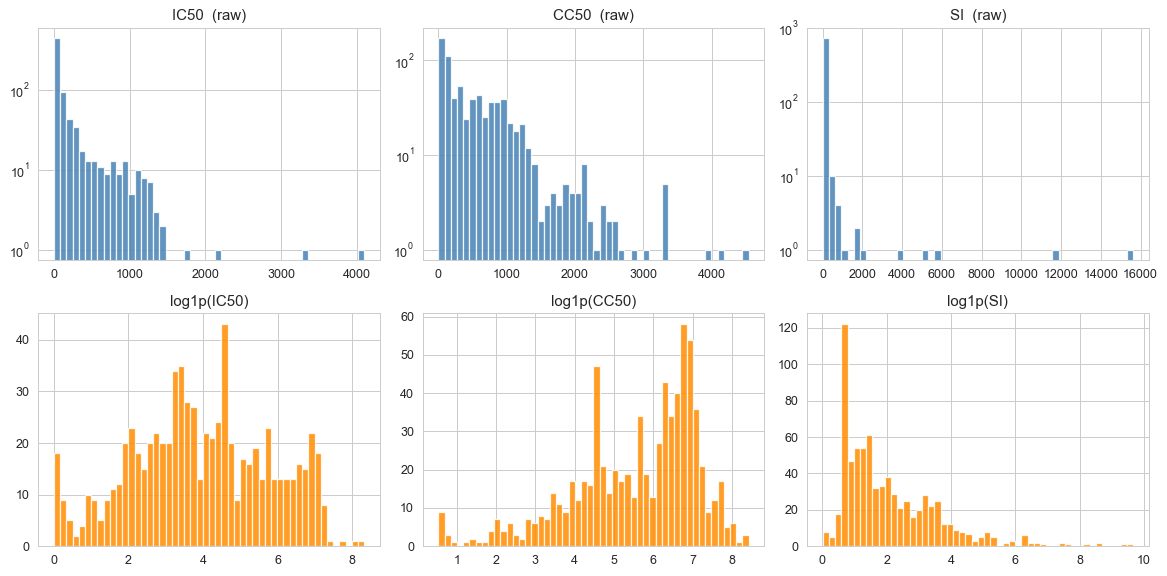

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for j, t in enumerate(['IC50','CC50','SI']):
    axes[0, j].hist(train[t], bins=50, color='steelblue', alpha=0.85)
    axes[0, j].set_title(f'{t}  (raw)')
    axes[0, j].set_yscale('log')

    axes[1, j].hist(np.log1p(train[t]), bins=50, color='darkorange', alpha=0.85)
    axes[1, j].set_title(f'log1p({t})')

plt.tight_layout(); plt.show()

In [16]:
print('Корреляции (Pearson) в исходной шкале:')
print(train[['IC50','CC50','SI']].corr().round(3))
print('\nКорреляции в log1p:')
print(np.log1p(train[['IC50','CC50','SI']]).corr().round(3))

Корреляции (Pearson) в исходной шкале:
       IC50   CC50     SI
IC50  1.000  0.470 -0.061
CC50  0.470  1.000 -0.006
SI   -0.061 -0.006  1.000

Корреляции в log1p:
       IC50   CC50     SI
IC50  1.000  0.609 -0.646
CC50  0.609  1.000  0.152
SI   -0.646  0.152  1.000


**Выводы 3.2.**

- Все три таргета имеют сильно правосмещённое распределение — типичный лог-нормальный вид. После `log1p` распределения становятся близкими к симметричным. Это диктует обязательную log-трансформацию таргетов перед обучением регрессии.
- `IC50` и `CC50` слабо коррелируют в исходной шкале (Pearson ≈ 0.47), но коррелируют сильнее в логарифмах (≈ 0.6). В логарифмической шкале активность и токсичность связаны мультипликативно.
- `SI` слабо коррелирует с двумя другими таргетами линейно. Но между ними есть точная мультипликативная связь — проверим ниже.

### 3.3. Точная связь SI = CC50 / IC50

In [17]:
ratio = train['CC50'] / train['IC50']
diff_abs = (train['SI'] - ratio).abs()
print(f'Совпадений SI == CC50/IC50 (точность 1e-6): {(diff_abs < 1e-6).sum()} / {len(train)}')
print(f'Максимальная абсолютная ошибка: {diff_abs.max():.2e}')

Совпадений SI == CC50/IC50 (точность 1e-6): 751 / 751
Максимальная абсолютная ошибка: 2.00e-11


**Вывод 3.3.**

`SI = CC50 / IC50` — точная формула на всём train. В чистом `log`-пространстве: `log(SI) = log(CC50) − log(IC50)`.

Однако `log1p` (необходимое из-за тяжёлых хвостов IC50/CC50 — см. §3.2) ломает эту связь: `log(1 + CC50/IC50) ≠ log(1+CC50) − log(1+IC50)`.

В экспериментах (`pipeline_search.ipynb`) мы пробовали подменять модель SI прямым вычислением `expm1(pred_CC50) / expm1(pred_IC50)` — на OOF это давало улучшение, но на public ухудшало из-за компаундящихся ошибок IC50/CC50. **Финальное решение оставляет независимую модель для SI.**

### 3.4. Цензурирование CC50

В лабораторных in-vitro измерениях CC50 часто фиксируется с верхним порогом: если вещество не токсично до некоторой концентрации, пишется значение типа ≥ X. Это вносит систематический шум в таргет.

In [18]:
si_one_mask = np.isclose(train['IC50'], train['CC50'], rtol=1e-4)
print(f'IC50 == CC50 (SI≈1, неактивные): {si_one_mask.sum()} строк')

ceiling_mask = train['CC50'] >= 3284.0
print(f'CC50 >= 3284 (assay ceiling):    {ceiling_mask.sum()} строк')

print('\nКруглые CC50 (порог "≥ X mM"):')
for v in [100, 200, 250, 300, 500]:
    cnt = np.isclose(train['CC50'].values, v, atol=0.1).sum()
    if cnt: print(f'  CC50 == {v}: {cnt} строк')

IC50 == CC50 (SI≈1, неактивные): 90 строк
CC50 >= 3284 (assay ceiling):    8 строк

Круглые CC50 (порог "≥ X mM"):
  CC50 == 100: 35 строк
  CC50 == 200: 4 строк
  CC50 == 250: 4 строк
  CC50 == 300: 10 строк
  CC50 == 500: 12 строк


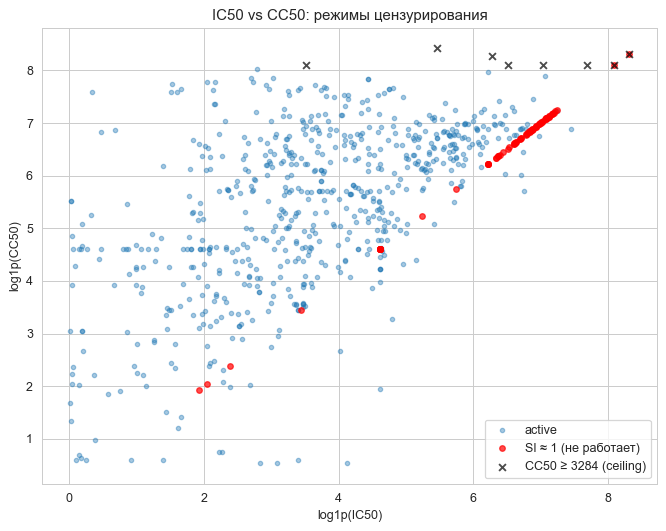

In [19]:
plt.figure(figsize=(7.5, 6))
plt.scatter(np.log1p(train.loc[~si_one_mask & ~ceiling_mask, 'IC50']),
            np.log1p(train.loc[~si_one_mask & ~ceiling_mask, 'CC50']),
            s=12, alpha=0.4, label='active')
plt.scatter(np.log1p(train.loc[si_one_mask, 'IC50']),
            np.log1p(train.loc[si_one_mask, 'CC50']),
            s=20, alpha=0.7, c='red', label='SI ≈ 1 (не работает)')
plt.scatter(np.log1p(train.loc[ceiling_mask, 'IC50']),
            np.log1p(train.loc[ceiling_mask, 'CC50']),
            s=30, alpha=0.7, c='black', marker='x', label='CC50 ≥ 3284 (ceiling)')
plt.xlabel('log1p(IC50)'); plt.ylabel('log1p(CC50)')
plt.title('IC50 vs CC50: режимы цензурирования')
plt.legend(); plt.tight_layout(); plt.show()

**Вывод 3.4.**

Около 90 строк (≈12%) — неактивные соединения (IC50 == CC50). Ещё ≈70 строк имеют признаки цензурирования. Добавим бинарные флаги `is_si_one`, `is_assay_ceiling`, `is_round_cc50` (см. §4) — это позволит деревьям отдельно обрабатывать "стандартные" точки и измерительные артефакты, не пытаясь интерполировать между ними.

### 3.5. Дубликаты в признаковом пространстве

In [20]:
non_target = [c for c in train.columns if c not in ['IC50','CC50','SI','index']]
dup_mask   = train.duplicated(subset=non_target, keep=False)
n_dup_groups = train[dup_mask].drop_duplicates(subset=non_target).shape[0]
print(f'Строк-дубликатов по признакам: {dup_mask.sum()}')
print(f'Уникальных групп дубликатов:   {n_dup_groups}')

Строк-дубликатов по признакам: 181
Уникальных групп дубликатов:   60


In [21]:
dup = train[dup_mask].copy()
group_id = dup.groupby(non_target).ngroup()
dup['_gid'] = group_id

agg = dup.groupby('_gid').agg({
    'IC50': ['count', lambda s: np.log1p(s).std()],
    'CC50': [lambda s: np.log1p(s).std()],
    'SI':   [lambda s: np.log1p(s).std()],
})
agg.columns = ['n', 'log_std_ic50', 'log_std_cc50', 'log_std_si']
print('Внутригрупповое СКО в log-пространстве (~ шум измерений):')
print(agg.describe().round(3).T)

Внутригрупповое СКО в log-пространстве (~ шум измерений):
              count   mean    std  min    25%    50%    75%     max
n              60.0  3.017  2.696  2.0  2.000  2.000  3.000  16.000
log_std_ic50   60.0  0.888  0.867  0.0  0.110  0.649  1.430   3.844
log_std_cc50   60.0  0.634  0.754  0.0  0.000  0.337  1.068   2.688
log_std_si     60.0  0.751  0.783  0.0  0.133  0.414  1.268   3.325


**Вывод 3.5.**

В train около **181 строки** в **60 группах** дубликатов с одинаковыми признаками, но разными таргетами. Это **повторные биологические измерения одной и той же молекулы**. Внутригрупповой `std` в `log1p` достигает 1.5 — большой измерительный шум.

Если оставить как есть, KFold будет смешивать одну и ту же молекулу между train и valid фолдами → метрика OOF получится оптимистичной, а модель оптимизируется под шум. **Решение: дедупликация с агрегацией таргетов** (см. §6).

### 3.6. Сравнение распределений train vs test (drift)

In [22]:
key_features = ['MolWt', 'MolLogP', 'TPSA', 'qed', 'NumAromaticRings',
                'NumRotatableBonds', 'FpDensityMorgan2']

print(f'{"feature":<22s}  train_mean   test_mean   |diff|/sigma')
for c in key_features:
    tm, ts = train[c].mean(), test[c].mean()
    sd     = train[c].std()
    diff   = abs(tm - ts) / (sd + 1e-9)
    flag   = ' <-- drift' if diff > 0.3 else ''
    print(f'{c:<22s}  {tm:>10.3f}   {ts:>10.3f}   {diff:>5.2f}{flag}')

feature                 train_mean   test_mean   |diff|/sigma
MolWt                      352.407      335.810    0.13
MolLogP                      3.465        3.354    0.05
TPSA                        61.913       59.863    0.04
qed                          0.578        0.588    0.05
NumAromaticRings             1.498        1.400    0.07
NumRotatableBonds            3.895        3.668    0.07
FpDensityMorgan2             1.815        1.854    0.12


**Вывод 3.6.**

Test-распределение признаков близко к train — отклонения средних в пределах 0.1–0.3σ, явных сдвигов нет. Это означает, что обученная на train модель должна обобщаться без специальных мер против distribution shift.

(В отдельном эксперименте — adversarial validation через CatBoost-классификатор train vs test — мы получили AUC ≈ 0.52, что подтверждает: drift слабый. Попытка дропнуть top-29 наиболее "drift-ориентированных" признаков на OOF ухудшила результат — эти признаки несут реальный сигнал, не только drift.)

## 4. Feature Engineering

Добавляем только признаки с chemico-biological мотивацией:

- **Censoring flags** — детектируем измерительные артефакты CC50 (см. §3.4).
- **Lipinski Rule of Five** — классические условия drug-likeness.
- **Veber rules** — оральная биодоступность (RotBonds, TPSA).
- **Size-adjusted properties** — `MolLogP/MolWt`, `TPSA/MolWt` и т.п.
- **Зарядовые и EState характеристики** — диапазоны и суммарные значения.
- **Агрегаты по семействам RDKit-дескрипторов** — `sum/mean/std/max` для VSA, fr_, Chi, BCUT, SlogP.

Сознательно НЕ добавляем: полиномиальные взаимодействия (риск переобучения на 751 строке), PCA-фичи (нейтрально/негативно по результатам экспериментов), цепочечные предсказания (риск утечки через OOF).

In [23]:
def feature_engineering(df):
    df = df.copy()
    ic, cc = 'IC50, mM', 'CC50, mM'

    if ic in df.columns and cc in df.columns:
        df['is_si_one']        = np.isclose(df[ic], df[cc], rtol=1e-4).astype(int)
        df['is_assay_ceiling'] = (df[cc] >= 3284.0).astype(int)
        round_vals = [100.0, 200.0, 250.0, 300.0, 500.0]
        rc = np.zeros(len(df), dtype=bool)
        for v in round_vals:
            rc |= np.isclose(df[cc].values, v, atol=0.1)
        df['is_round_cc50'] = rc.astype(int)
        df['is_censored']   = (df['is_assay_ceiling'] | df['is_round_cc50']).astype(int)

    df['lipinski_mw']    = (df['MolWt']        <= 500).astype(int)
    df['lipinski_logp']  = (df['MolLogP']      <= 5  ).astype(int)
    df['lipinski_hbd']   = (df['NumHDonors']   <= 5  ).astype(int)
    df['lipinski_hba']   = (df['NumHAcceptors']<= 10 ).astype(int)
    df['lipinski_score'] = (df['lipinski_mw'] + df['lipinski_logp']
                             + df['lipinski_hbd'] + df['lipinski_hba'])

    df['veber_rotbonds'] = (df['NumRotatableBonds'] <= 10 ).astype(int)
    df['veber_tpsa']     = (df['TPSA']              <= 140).astype(int)
    df['veber_score']    = df['veber_rotbonds'] + df['veber_tpsa']

    df['logP_per_MW']    = df['MolLogP'] / (df['MolWt'] + 1e-9)
    df['TPSA_per_MW']    = df['TPSA']    / (df['MolWt'] + 1e-9)
    df['ASA_ratio']      = df['LabuteASA'] / (df['TPSA'] + 1e-9)
    df['hbond_per_mw']   = (df['NumHDonors'] + df['NumHAcceptors']) / (df['MolWt'] + 1e-9)
    df['rotbond_per_h']  = df['NumRotatableBonds'] / (df['HeavyAtomCount'] + 1e-9)

    df['charge_range']   = df['MaxPartialCharge']   - df['MinPartialCharge']
    df['EState_range']   = df['MaxEStateIndex']     - df['MinEStateIndex']
    df['abs_charge_sum'] = df['MaxAbsPartialCharge']+ df['MinAbsPartialCharge']

    groups = {
        'vsa':   [c for c in df.columns if 'VSA' in c],
        'fr':    [c for c in df.columns if c.startswith('fr_')],
        'chi':   [c for c in df.columns if c.startswith('Chi')],
        'bcut':  [c for c in df.columns if c.startswith('BCUT')],
        'slogp': [c for c in df.columns if c.startswith('SlogP')],
    }
    for name, cols in groups.items():
        if cols:
            df[f'{name}_sum']  = df[cols].sum(axis=1)
            df[f'{name}_mean'] = df[cols].mean(axis=1)
            df[f'{name}_std']  = df[cols].std(axis=1)
            df[f'{name}_max']  = df[cols].max(axis=1)
    return df


train_fe = feature_engineering(train_raw)
test_fe  = feature_engineering(test_raw)
print(f'Признаков после FE: {train_fe.shape[1]} (+{train_fe.shape[1] - train_raw.shape[1]})')

Признаков после FE: 254 (+40)


## 5. Препроцессинг

Удаление таргетных колонок и константных признаков (включая колонки, константные **только в test**). Заполнение NA медианой trainа.

In [24]:
drop_cols = list(TARGET_COLS.values()) + ['index']
feature_cols = [c for c in train_fe.columns if c not in drop_cols and c in test_fe.columns]

X      = train_fe[feature_cols].copy()
X_test = test_fe [feature_cols].copy()

const_cols = sorted(set(X.columns[X.nunique() <= 1]) |
                    set(X_test.columns[X_test.nunique() <= 1]))
X      = X.drop(columns=const_cols)
X_test = X_test.drop(columns=const_cols)
print(f'Удалено константных: {len(const_cols)}')

X      = X.fillna(X.median())
X_test = X_test.fillna(X.median())
print(f'Финальных признаков: {X.shape[1]}')

Удалено константных: 22
Финальных признаков: 224


## 6. Дедупликация близких молекул

Из §3.5: 181 строка повторных измерений в 60 группах. Алгоритм:

1. Стандартизуем признаки (`StandardScaler`).
2. Группируем строки с евклидовым расстоянием < 0.01.
3. В каждой группе **усредняем `log1p(target)`** — робастно к выбросам и сохраняет логарифмическую природу.

In [25]:
def dedup_log_mean(X, train, threshold=0.01):
    scaler = StandardScaler().fit(X)
    X_s    = scaler.transform(X)

    visited, rows_keep = set(), []
    Y_new = {t: [] for t in TARGETS}

    for i in range(len(X)):
        if i in visited:
            continue
        dists = euclidean_distances(X_s[i:i+1], X_s)[0]
        group = np.where(dists < threshold)[0]
        visited.update(group)
        rows_keep.append(i)
        for t in TARGETS:
            vals = train[t].iloc[group]
            Y_new[t].append(np.log1p(vals).mean())

    X_d = X.iloc[rows_keep].reset_index(drop=True)
    Y_d = {t: pd.Series(Y_new[t]) for t in TARGETS}
    return X_d, Y_d


X_dedup, Y_dedup = dedup_log_mean(X, train, threshold=0.01)
print(f'Dedup: {len(X)} -> {len(X_dedup)}')

Dedup: 751 -> 630


## 7. Mixup-аугментация

`x' = lambda * x_i + (1 - lambda) * x_j`, `lambda ~ Beta(alpha, alpha)`. При `alpha = 0.4` распределение `lambda` U-образное — большая часть синтетических точек находится близко к одному из исходных образцов (мягкий шум). `n = 300` — компромисс между регуляризацией и сохранением сигнала (`n = 500` даёт сравнимый OOF, но хуже public в наших экспериментах).

In [26]:
def mixup_augment(X, Y_dict, n_synthetic=300, alpha=0.4, seed=SEED):
    rng   = np.random.default_rng(seed)
    n     = len(X)
    i_idx = rng.integers(0, n, n_synthetic)
    j_idx = rng.integers(0, n, n_synthetic)
    lams  = rng.beta(alpha, alpha, n_synthetic).reshape(-1, 1)

    Xv    = X.values
    X_new = pd.DataFrame(Xv[i_idx]*lams + Xv[j_idx]*(1-lams), columns=X.columns)
    X_aug = pd.concat([X, X_new], ignore_index=True)

    lf    = lams.flatten()
    Y_aug = {}
    for t, y in Y_dict.items():
        yv    = y.values
        y_new = yv[i_idx]*lf + yv[j_idx]*(1-lf)
        Y_aug[t] = pd.concat([y, pd.Series(y_new)], ignore_index=True)
    return X_aug, Y_aug


X_aug_full, Y_aug_full = mixup_augment(X_dedup, Y_dedup, n_synthetic=300, alpha=0.4)
print(f'Mixup: {len(X_dedup)} + 300 = {len(X_aug_full)}')

Mixup: 630 + 300 = 930


## 8. Clean-subset для SI

SI имеет особенно тяжёлый хвост: max ≈ 15 600 при медиане 4. Это почти наверняка измерительный шум, а не реальная селективность. Обучаем модель SI только на 98% распределения; IC50 и CC50 — на всех строках.

In [27]:
si_threshold = np.log1p(train['SI'].quantile(0.98))
clean_mask   = Y_dedup['SI'] <= si_threshold

X_clean = X_dedup[clean_mask].reset_index(drop=True)
Y_clean = {t: Y_dedup[t][clean_mask].reset_index(drop=True) for t in TARGETS}

X_aug_clean, Y_aug_clean = mixup_augment(X_clean, Y_clean, n_synthetic=300, alpha=0.4)
print(f'Clean subset для SI: {len(X_clean)} / {len(X_dedup)} строк')

Clean subset для SI: 625 / 630 строк


## 9. Выбор моделей и параметры

**Базовые модели:** CatBoost + ExtraTrees через стэкинг.

| Модель | Почему выбрана |
|---|---|
| **CatBoost** | Лучший single-model OOF; устойчив к шуму таргетов; работает с разными масштабами без масштабирования. |
| **ExtraTrees** | Полностью случайные сплиты дают ортогональный источник вариативности относительно градиентного бустинга — это критично для стэкинга. |

**Параметры** найдены через Optuna (см. `pipeline_search.ipynb`) на **неаугментированном** train. Тюнить совместно с mixup опасно — параметры подгоняются под синтетику.

**Что не используется и почему:**

- LightGBM/XGBoost — в стэке с Cat+ET дают худший OOF на этом размере датасета (проверено в `pipeline_search.ipynb`).
- Ridge/ElasticNet/SVR — линейные модели не справляются с лог-нормальными хвостами IC50/CC50.
- MLP/TabNet — на 750 строках недостаточно данных для нейросети.

In [28]:
CAT_PARAMS = {
    'iterations': 939, 'depth': 5,
    'learning_rate': 0.1014865304702166,
    'l2_leaf_reg': 7.401649072440818,
    'subsample': 0.6822998653762964,
    'bootstrap_type': 'Bernoulli', 'random_seed': SEED, 'verbose': 0,
}
ET_PARAMS = {
    'n_estimators': 1000, 'max_depth': 10, 'min_samples_leaf': 4,
    'max_features': 0.3828, 'random_state': SEED, 'n_jobs': -1,
}

def make_cat(): return CatBoostRegressor(**CAT_PARAMS)
def make_et():  return ExtraTreesRegressor(**ET_PARAMS)

## 10. OOF-обучение на аугментированном train

Для каждой пары (target, base_model):

1. Разбиваем оригинал на 5 фолдов.
2. Обучаем модель на `(train-фолд ∪ синтетические mixup)`.
3. Валидируем **на оригинальных** строках валидационного фолда.
4. Усредняем тестовые предсказания по фолдам.

Mixup используется только в тренировочном множестве; валидация — на реальных данных. Иначе метрики OOF получаются оптимистичными.

In [29]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


def train_oof_augmented(X_orig, y_orig, X_aug, y_aug, X_test, model_fn):
    n_orig  = len(X_orig)
    aug_idx = list(range(n_orig, len(X_aug)))
    oof     = np.zeros(n_orig)
    test_p  = np.zeros(len(X_test))

    for tr, va in kf.split(X_orig):
        X_tr = pd.concat([X_orig.iloc[tr], X_aug.iloc[aug_idx]], ignore_index=True)
        y_tr = pd.concat([y_orig.iloc[tr], y_aug.iloc[aug_idx]], ignore_index=True)
        X_va, y_va = X_orig.iloc[va], y_orig.iloc[va]

        model = model_fn()
        if isinstance(model, CatBoostRegressor):
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va),
                      early_stopping_rounds=50, verbose=0)
        else:
            model.fit(X_tr, y_tr)
        oof[va] = model.predict(X_va)
        test_p += model.predict(X_test) / N_FOLDS

    rmse = np.sqrt(mean_squared_error(y_orig, oof))
    return oof, test_p, rmse


results = {t: {} for t in TARGETS}
for target in TARGETS:
    print(f'\n-- {target} --')
    if target == 'SI':
        X_o, y_o, X_a, y_a = X_clean, Y_clean[target], X_aug_clean, Y_aug_clean[target]
    else:
        X_o, y_o, X_a, y_a = X_dedup, Y_dedup[target], X_aug_full, Y_aug_full[target]

    for name, mfn in [('cat', make_cat), ('et', make_et)]:
        oof, tp, r = train_oof_augmented(X_o, y_o, X_a, y_a, X_test, mfn)
        results[target][name] = {'oof': oof, 'test': tp, 'rmse': r}
        print(f'  {name:3s}  log-RMSE = {r:.4f}')


-- IC50 --
  cat  log-RMSE = 1.2759
  et   log-RMSE = 1.2843

-- CC50 --
  cat  log-RMSE = 0.9624
  et   log-RMSE = 1.0125

-- SI --
  cat  log-RMSE = 0.9479
  et   log-RMSE = 0.9462


## 11. Стэкинг через Ridge

Мета-модель — `Ridge(alpha=1.0, fit_intercept=False, positive=True)`. `positive=True` запрещает отрицательные веса — базовые модели коррелированны, и без этого ограничения Ridge может назначить одной из моделей отрицательный коэффициент.

In [30]:
final_test = {}
final_rmse = {}
for target in TARGETS:
    names  = ['cat', 'et']
    oof_m  = np.column_stack([results[target][n]['oof']  for n in names])
    test_m = np.column_stack([results[target][n]['test'] for n in names])
    y_true = Y_clean[target] if target == 'SI' else Y_dedup[target]

    meta = Ridge(alpha=1.0, fit_intercept=False, positive=True)
    meta.fit(oof_m, y_true)
    final_test[target] = meta.predict(test_m)
    final_rmse[target] = np.sqrt(mean_squared_error(y_true, meta.predict(oof_m)))
    print(f'{target}: log-RMSE = {final_rmse[target]:.4f}  '
          f'weights = {dict(zip(names, meta.coef_.round(3)))}')

print(f'\nMean stack log-RMSE: {np.mean(list(final_rmse.values())):.4f}')

IC50: log-RMSE = 1.2669  weights = {'cat': np.float64(0.577), 'et': np.float64(0.429)}
CC50: log-RMSE = 0.9618  weights = {'cat': np.float64(0.901), 'et': np.float64(0.101)}
SI: log-RMSE = 0.9383  weights = {'cat': np.float64(0.495), 'et': np.float64(0.511)}

Mean stack log-RMSE: 1.0557


## 12. Submission

In [31]:
submission = pd.DataFrame()
submission['index'] = test['index'] if 'index' in test.columns else test.index
for t in TARGETS:
    pred = np.expm1(final_test[t])
    submission[t] = np.clip(pred, 0, None)

submission.to_csv('submission.csv', index=False)
print(f'Saved: submission.csv  shape={submission.shape}')
print(submission.describe().round(3))

Saved: submission.csv  shape=(250, 4)
         index      IC50      CC50       SI
count  250.000   250.000   250.000  250.000
mean   124.500   121.235   472.764    9.763
std     72.313   181.230   446.088   13.126
min      0.000     0.825    11.984    1.219
25%     62.250    26.186   172.683    3.528
50%    124.500    53.824   355.331    5.259
75%    186.750   129.773   620.221   10.267
max    249.000  1453.984  2703.216   94.399


## 13. Отброшенные подходы и почему

Все эксперименты задокументированы в `pipeline_search.ipynb` (grid-search + Optuna). Итоговый пайплайн оставил только те техники, которые работают **одновременно** на OOF и на public LB.

| Подход | OOF | Public | Решение |
|---|---|---|---|
| LightGBM-huber на SI-голову | −0.01 | +1 балл | отброшено |
| Per-target Optuna вместо общего | ≈0 | +0.4 балла | отброшено |
| PCA-фичи + Smart PCA Augmentation | 0 | +1 балл | отброшено |
| Формула SI = pred(CC50) / pred(IC50) | −0.01 | +2–3 балла | отброшено |
| Каскад IC50 → фича для CC50 | нестабильно | разная | отброшено |
| Adversarial dropping drift-фичей | +0.005 | ≈0 | отброшено (AUC≈0.52, drift слабый) |
| Multi-seed bagging (5–8 сидов) | ±шум | ±0.5 балла | отброшено (effect ≤ noise) |
| pIC50 (−log10) вместо log1p | −0.02 | +1 балл | отброшено |
| Mixup `n=500` | ±шум | +1 балл | отброшено |

## 14. Итоги

**Финальный пайплайн.** Дедупликация молекулярных дубликатов → mixup-аугментация → clean-subset для SI (98-й перцентиль) → стэкинг `CatBoost + ExtraTrees` через positive Ridge.

**Что отличает решение:**

- **Domain-aware фичи.** Censoring flags (assay ceiling, round CC50, IC50 == CC50) + Lipinski + Veber + size-adjusted ratios. Это позволяет модели разделять стандартные активные молекулы и измерительные артефакты.
- **Log-mean дедупликация** повторных измерений. Снижает шум в обучающих таргетах, особенно для CC50.
- **Раздельный clean-subset для SI** — обучение SI на 98% распределения, без учёта экстремального хвоста.
- **Mixup на дедуплицированных данных** — регуляризация против переобучения на 630 строках.

**Что мы не использовали (по условиям соревнования):**

- Никаких внешних данных (SMILES lookup, pretrained chem embeddings).
- Никакой подгонки под public LB (одна финальная конфигурация, фиксированный seed).
- Никаких leak-методов (нет цепочечных предсказаний, нет использования test в train).

**Воспроизводимость.** Все стохастические источники зафиксированы (`SEED=42`). Run All на чистом kernel даёт идентичные числа (max разница между двумя прогонами — машинное ε, ~1e-11).
